In [6]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [7]:
dataset_path="../data/PlantVillage"
print(os.path.exists(dataset_path))

True


In [8]:
os.listdir(dataset_path)

['Tomato_healthy',
 'Potato___Early_blight',
 'Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Tomato_Early_blight',
 'Tomato__Target_Spot',
 'Potato___Late_blight',
 'Tomato_Leaf_Mold',
 'Tomato_Spider_mites_Two_spotted_spider_mite',
 'Tomato_Septoria_leaf_spot',
 'Tomato__Tomato_mosaic_virus',
 'Pepper__bell___Bacterial_spot',
 'Tomato_Bacterial_spot',
 'Tomato_Late_blight',
 'Pepper__bell___healthy',
 'Potato___healthy']

In [9]:
classes=sorted([
    d for d in os.listdir(dataset_path)
    if d!=".DS_Store"
])
print(len(classes))

15


In [10]:
class_counts = {}

for cls in classes:
    count = len([
        f for f in os.listdir(os.path.join(dataset_path,cls))
        if not f.startswith(".")
        ])
    class_counts[cls]=count
for cls,count in class_counts.items():
    print(f"{cls}:{count}")

print("\n Total Images:",sum(class_counts.values()))

Pepper__bell___Bacterial_spot:997
Pepper__bell___healthy:1478
Potato___Early_blight:1000
Potato___Late_blight:1000
Potato___healthy:152
Tomato_Bacterial_spot:2127
Tomato_Early_blight:1000
Tomato_Late_blight:1909
Tomato_Leaf_Mold:952
Tomato_Septoria_leaf_spot:1771
Tomato_Spider_mites_Two_spotted_spider_mite:1676
Tomato__Target_Spot:1404
Tomato__Tomato_YellowLeaf__Curl_Virus:3209
Tomato__Tomato_mosaic_virus:373
Tomato_healthy:1591

 Total Images: 20639


In [11]:
df=pd.DataFrame(
    class_counts.items(),
    columns=["Class","Image Count"]
)
df

,Class,Image Count
0,Pepper__bell___Bacterial_spot,997
1,Pepper__bell___healthy,1478
2,Potato___Early_blight,1000
3,Potato___Late_blight,1000
4,Potato___healthy,152
5,Tomato_Bacterial_spot,2127
6,Tomato_Early_blight,1000
7,Tomato_Late_blight,1909
8,Tomato_Leaf_Mold,952
9,Tomato_Septoria_leaf_spot,1771


In [12]:
df["Image Count"].describe()

count      15.000000
mean     1375.933333
std       744.654615
min       152.000000
25%       998.500000
50%      1404.000000
75%      1723.500000
max      3209.000000
Name: Image Count, dtype: float64

<Figure size 1200x800 with 0 Axes>

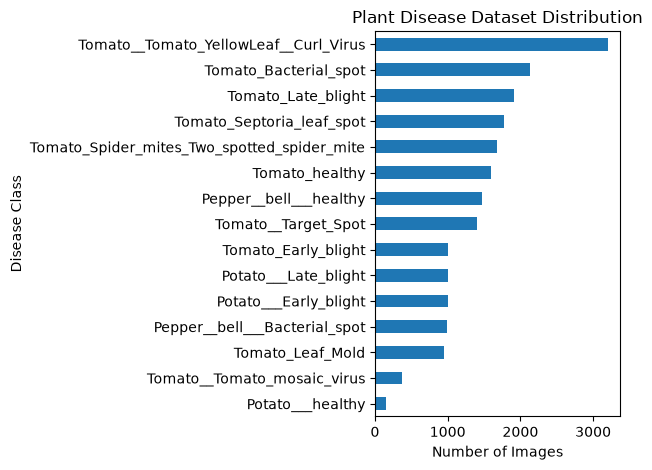

In [13]:
plt.figure(figsize=(12,8))

df.sort_values("Image Count").plot(
    x="Class",
    y="Image Count",
    kind="barh",
    legend=False
)
plt.title("Plant Disease Dataset Distribution")
plt.xlabel("Number of Images")
plt.ylabel("Disease Class")

plt.tight_layout()
plt.show()

# Week 1 Observations

## Dataset Overview

The PlantVillage dataset used in this project contains 15 disease classes belonging to Bell Pepper, Potato, and Tomato crops.

### Key Statistics

- Total Classes: 15
- Total Images: 20,639
- Largest Class: Tomato Yellow Leaf Curl Virus (3,209 images)
- Smallest Class: Potato Healthy (152 images)

### Findings

- The dataset is imbalanced.
- Tomato diseases constitute the majority of the dataset.
- Healthy classes contain fewer samples than several disease classes.
- Images are organized into class-specific directories, making them suitable for supervised image classification.

### Next Steps

- Perform image preprocessing.
- Resize images to a fixed dimension.
- Apply data augmentation.
- Create train, validation, and test datasets.
- Train a baseline CNN model.